In [ ]:
import Functional_Fusion.reliability as rel
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from OptimalBattery.global_config import data_path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)

  
# Load data
MDTB_dataset = DataSetMDTB(f'{data_path}/FunctionalFusion_new/MDTB')

subj = None

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun',subj=subj)
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

In [18]:
n_cond = info_mdtb_1_run['cond_num'].nunique()
print(f'Number of conditions: {n_cond}')

n_part = info_mdtb_1_run['run'].nunique()
print(f'Number of partitions: {n_part}')

Number of conditions: 29
Number of partitions: 16


In [19]:
cond_vec = np.tile(np.arange(1, n_cond + 1), n_part)
part_vec = np.repeat(np.arange(1, n_part + 1), n_cond)


In [20]:
var = rel.decompose_subj_group(data_mdtb_s1_run, cond_vec, part_vec,separate='subject_wise')


In [21]:
combined = (var[:, 0] + var[:, 1]).tolist()
print(combined)

[0.0196991187488852, 0.0291119097017132, 0.009868315372056239, 0.02666920728512233, 0.012530722513964174, 0.023969897215134296, 0.026436919129805385, 0.019008834666825788, 0.014048736255142842, 0.018222607813836222, 0.03655696258923394, 0.00945854991438873, 0.017826522554411507, 0.016721016465301754, 0.01134745499645742, 0.027609353003180823, 0.019002938368900588, 0.014779159602009994, 0.019332472019233885, 0.012547128382596882, 0.015449975415808167, 0.017610806336780898, 0.009659853650544005, 0.007693769241799343]


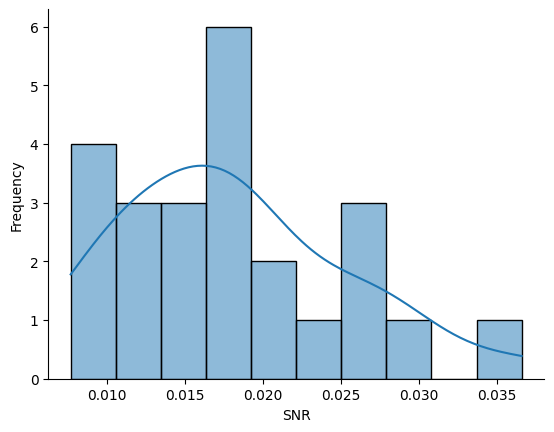

In [22]:
snr_list = combined
sns.histplot(snr_list, bins=10, kde=True)
plt.xlabel("SNR")
plt.ylabel("Frequency")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()